## importing Libraries

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

## Loading Train-Test Files

In [11]:
X_train = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\processed_data\train\X_train.csv")
X_test = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\processed_data\test\X_test.csv")

y_train = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\processed_data\train\y_train.csv")
y_test = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\processed_data\test\y_test.csv")

print(X_train.shape)
print(X_test.shape)


(5634, 35)
(1409, 35)


## Flatten Target Variable

In [12]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(type(y_train))

<class 'pandas.core.series.Series'>


## Train Baseline Model

In [13]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

print("Training Completed")

Training Completed


c:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Making Predictions

In [14]:
y_pred = lr.predict(X_test)

y_pred[:10]

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

## Evaluate Model

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9190915542938254
Precision: 0.8403141361256544
Recall   : 0.8582887700534759
F1 Score : 0.8492063492063492


## Confusion Matrix

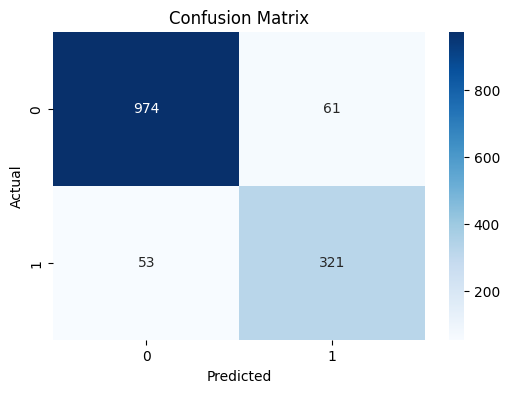

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification Report

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1035
           1       0.84      0.86      0.85       374

    accuracy                           0.92      1409
   macro avg       0.89      0.90      0.90      1409
weighted avg       0.92      0.92      0.92      1409



## ROC-AUC Score

In [19]:
probabilities = lr.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test,probabilities)

print("ROC-AUC:", auc)

ROC-AUC: 0.9755664057454339


## ROC Curve

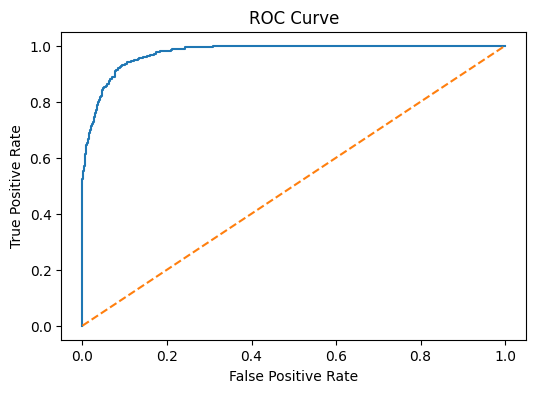

In [21]:
fpr, tpr, _ = roc_curve(y_test,probabilities)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

## Train Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained")

Random Forest Trained


## Evaluate Random Forest

In [23]:
print("Accuracy:",accuracy_score(y_test, rf_pred))

print("F1:",f1_score(y_test, rf_pred))

Accuracy: 0.9318665720369056
F1: 0.8709677419354839


## Train XGBoost

In [24]:
xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

## Train LightBGM

In [44]:
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("LightGBM Trained Successfully")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1495
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
LightGBM Trained Successfully


## Evaluate LightGBM

In [45]:
print("Accuracy:",accuracy_score(y_test, lgbm_pred))

print("F1 Score:",f1_score(y_test, lgbm_pred))

Accuracy: 0.9297374024130589
F1 Score: 0.8695652173913043


## Model Comparison

In [58]:
results = pd.DataFrame({
    
       "Model":["Logistic Regression","Random Forest",
                "XGBoost","LightGBM"],
       
    "Accuracy":[accuracy_score(y_test,y_pred),
                accuracy_score(y_test,rf_pred),
                accuracy_score(y_test,xgb_pred),
                accuracy_score(y_test,lgbm_pred)],
    
        "F1":[  f1_score(y_test,y_pred),
                f1_score(y_test,rf_pred),
                f1_score(y_test,xgb_pred),
                f1_score(y_test,lgbm_pred)]})

results.sort_values(by="F1",ascending=False)

,Model,Accuracy,F1
1,Random Forest,0.931867,0.870968
3,LightGBM,0.929737,0.869565
2,XGBoost,0.924769,0.859043
0,Logistic Regression,0.919092,0.849206


## Creating Model Folder

In [47]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


## Saving All Models

In [ ]:
joblib.dump(lr,"C:\\Users\\Hey!\\OneDrive\\Desktop\Customer churn prediction & retention Platform\\models\\logistic_regression.pkl")
joblib.dump(rf,"C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\models\\random_forest.pkl")
joblib.dump(xgb,"C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\models\\xgboost.pkl")
joblib.dump(lgbm,"C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\models\\lightgbm.pkl")

print("All models saved successfully.")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Hey!\AppData\Local\Temp\ipykernel_21396\1270648497.py:1: SyntaxWarning: invalid escape sequence '\C'
  joblib.dump(lr, "C:\\Users\\Hey!\\OneDrive\\Desktop\Customer churn prediction & retention Platform\\models\\logistic_regression.pkl")


All models saved successfully.


## Saving Best Model

In [53]:
joblib.dump(rf, "C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\models\\best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## Verifying Saved Models

In [56]:
import os

print(os.listdir("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\models"))

['best_model.pkl', 'lightgbm.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'xgboost.pkl']


## Saving Comparison Results

In [57]:
results.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\reports\\model_comparison.csv",index=False)

print("Comparison report saved.")

Comparison report saved.
